In [1]:
import numpy as np
import pandas as pd

In [9]:
df = pd.read_csv('raw_cems_data_cleaned.csv')

In [11]:
df

,Record_ID,Plant_ID,Stack_ID,Flow_Rate_m3_hr,TS,PM2.5,SO2,NOx,Unit,Status,Lat_Lon,Source_Type,Exceedance_Flag,Audit_Hash
0,E00001,PL-01,S-01,2033.5,2025-01-01 00:00:00,166.47,116.47,100.88,ug/m3,FAULT,"13.083,80.2702",Stack,EXCEEDANCE,d71814caf8869de73c7cb0f4961d17dc5d876a10c9e8ff...
1,E00002,PL-01,S-02,3377.9,2025-01-01 00:00:00,0.82,95.92,32.04,ug/m3,MAINT,"13.0839,80.2721",Stack,OK,c56bf3f67a43a284fa48f2ecc24d2d9e09ec5a29cbb631...
2,E00003,PL-02,S-01,3798.4,2025-01-01 00:00:00,273.80,NaN,267.00,ug/m3,FAULT,"19.0763,72.8777",Stack,EXCEEDANCE,dda06ae3b5d761c6aca0f62857256b9f503759d6fa399f...
3,E00004,PL-03,S-01,3121.2,2025-01-01 00:00:00,106.36,133.00,90.91,ug/m3,OK,"12.9719,77.5955",Stack,OK,788875f936a81b248de6e0d6e76db831ef72aa8f34cee3...
4,E00005,PL-03,S-02,3700.5,2025-01-01 00:00:00,273.80,275.70,267.00,ug/m3,FAULT,"12.9722,77.5941",Stack,EXCEEDANCE,9340d8147c38f065829c73ed5f8bb17f1f4c23e09d2343...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28795,E28796,PL-03,S-03,2725.5,2025-01-30 23:45:00,33.76,180.59,NaN,ug/m3,MAINT,"12.9709,77.5956",Stack,OK,957fcd5bd0f2c61755ac5dbb4f55b62db40f8c00cb6c7a...
28796,E28797,LOC-DEL-01,A-01,0.0,2025-01-30 23:45:00,NaN,139.50,104.80,ug/m3,FAULT,"28.614,77.2084",Ambient,EXCEEDANCE,46f901aedaff38bfb953f0aa27f8f914275015b2564667...
28797,E28798,LOC-DEL-02,A-02,0.0,2025-01-30 23:45:00,159.49,186.26,20.20,ug/m3,FAULT,"28.6209,77.2156",Ambient,EXCEEDANCE,7f25f6d8f2be1f495b399b6563657dd54fed1ce7e0212e...
28798,E28799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ug/m3,GAP_FILLED,NaN,Unknown,OK,0b4dd84f0e233e13717546091dca6892b28907a1a10fc1...


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28800 entries, 0 to 28799
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Record_ID        28800 non-null  object 
 1   Plant_ID         26385 non-null  object 
 2   Stack_ID         26385 non-null  object 
 3   Flow_Rate_m3_hr  21067 non-null  float64
 4   TS               26385 non-null  object 
 5   PM2.5            24467 non-null  float64
 6   SO2              24438 non-null  float64
 7   NOx              24435 non-null  float64
 8   Unit             28800 non-null  object 
 9   Status           28800 non-null  object 
 10  Lat_Lon          26224 non-null  object 
 11  Source_Type      28800 non-null  object 
 12  Exceedance_Flag  28800 non-null  object 
 13  Audit_Hash       28800 non-null  object 
dtypes: float64(4), object(10)
memory usage: 3.1+ MB


## Transformation

In [20]:
#1.
pm25_limit = 60
so2_limit = 80
nox_limit = 80 

df['PM25_Exceed'] = df['PM2.5'] > pm25_limit
df['SO2_Exceed'] = df['SO2'] > so2_limit
df['NOx_Exceed'] = df['NOx'] > nox_limit

df['Any_Exceedance'] = df[['PM25_Exceed', 'SO2_Exceed', 'NOx_Exceed']].any(axis = 1)

print(df[['PM2.5','SO2','NOx','Any_Exceedance']].head())

    PM2.5     SO2     NOx  Any_Exceedance
0  166.47  116.47  100.88            True
1    0.82   95.92   32.04            True
2  273.80     NaN  267.00            True
3  106.36  133.00   90.91            True
4  273.80  275.70  267.00            True


In [22]:
#2.

def calculate_aqi_pm25(c):
    if c <= 30:
        return (50/30)*c
    elif c <= 60:
        return 50 + (50/30)*(c-30)
    elif c <= 90:
        return 100 + (100/30)*(c-60)
    else:
        return 200 + (100/50)*(c-90)

df['AQI_PM25'] = df['PM2.5'].apply(calculate_aqi_pm25)

df['AQI_Overall'] = df[['AQI_PM25']].max(axis=1)

print(df[['PM2.5','AQI_PM25','AQI_Overall']].head())

    PM2.5    AQI_PM25  AQI_Overall
0  166.47  352.940000   352.940000
1    0.82    1.366667     1.366667
2  273.80  567.600000   567.600000
3  106.36  232.720000   232.720000
4  273.80  567.600000   567.600000


In [24]:
#3.

df['TS'] = pd.to_datetime(df['TS'])

df['PM25_kg_hr'] = (df['PM2.5'] * df['Flow_Rate_m3_hr']) / 1e6
df['SO2_kg_hr'] = (df['SO2'] * df['Flow_Rate_m3_hr']) / 1e6
df['NOx_kg_hr'] = (df['NOx'] * df['Flow_Rate_m3_hr']) / 1e6

daily_emission = df.resample('D', on='TS')[['PM25_kg_hr','SO2_kg_hr','NOx_kg_hr']].sum()

print(daily_emission.head())

            PM25_kg_hr   SO2_kg_hr   NOx_kg_hr
TS                                            
2025-01-01  230.303064  226.060633  205.299681
2025-01-02  208.962217  217.323251  202.294993
2025-01-03  197.015604  201.180459  193.939797
2025-01-04  216.989402  226.316641  236.872223
2025-01-05  207.756185  218.543447  229.939627


In [26]:
#4.

df = df.sort_values('TS')

df['PM25_24hr_avg'] = df['PM2.5'].rolling(window=24).mean()
df['SO2_24hr_avg'] = df['SO2'].rolling(window=24).mean()
df['NOx_24hr_avg'] = df['NOx'].rolling(window=24).mean()

pm25_percentiles = df['PM2.5'].quantile([0.5,0.75,0.9,0.95])
print(pm25_percentiles)

0.50    129.520
0.75    183.815
0.90    273.800
0.95    273.800
Name: PM2.5, dtype: float64


In [28]:
#5.

source_contribution = df.groupby('Source_Type')[['PM2.5','SO2','NOx']].mean()

source_percent = source_contribution / source_contribution.sum() * 100

print(source_percent)

                PM2.5        SO2       NOx
Source_Type                               
Ambient      49.42902  48.874407  49.35232
Stack        50.57098  51.125593  50.64768
Unknown           NaN        NaN       NaN


In [30]:
#6.

df['TS'] = pd.to_datetime(df['TS'])

df['Month'] = df['TS'].dt.to_period('M')
df['Compliant'] = ~df['Any_Exceedance']

compliance_rate = df.groupby(['Plant_ID','Month'])['Compliant'].mean() * 100

print(compliance_rate)

Plant_ID    Month  
LOC-BLR-01  2025-01    2.989028
LOC-DEL-01  2025-01    2.522590
LOC-DEL-02  2025-01    2.448211
LOC-MUM-01  2025-01    3.041825
PL-01       2025-01    2.928949
PL-02       2025-01    3.029141
PL-03       2025-01    2.759144
Name: Compliant, dtype: float64


In [32]:
#7....

df['High_PM25'] = df['PM2.5'] > 150

df['Episode'] = (df['High_PM25'] != df['High_PM25'].shift()).cumsum()

episodes = df[df['High_PM25']].groupby('Episode').agg(
    start_time=('TS','min'),
    end_time=('TS','max'),
    duration=('TS','count')
)

episodes = episodes[episodes['duration'] >= 3]

print(episodes)

                 start_time            end_time  duration
Episode                                                  
41      2025-01-01 01:30:00 2025-01-01 01:30:00         4
51      2025-01-01 02:15:00 2025-01-01 02:15:00         4
63      2025-01-01 02:45:00 2025-01-01 02:45:00         3
65      2025-01-01 03:00:00 2025-01-01 03:00:00         3
79      2025-01-01 03:45:00 2025-01-01 04:00:00         3
...                     ...                 ...       ...
12179   2025-01-30 21:45:00 2025-01-30 21:45:00         3
12195   2025-01-30 22:30:00 2025-01-30 22:30:00         3
12197   2025-01-30 22:45:00 2025-01-30 22:45:00         4
12205   2025-01-30 23:30:00 2025-01-30 23:45:00         3
12207   2025-01-30 23:45:00 2025-01-30 23:45:00         3

[806 rows x 3 columns]


In [36]:
from scipy.interpolate import griddata

In [40]:
print(df.columns)

Index(['Record_ID', 'Plant_ID', 'Stack_ID', 'Flow_Rate_m3_hr', 'TS', 'PM2.5',
       'SO2', 'NOx', 'Unit', 'Status', 'Lat_Lon', 'Source_Type',
       'Exceedance_Flag', 'Audit_Hash', 'PM25_Exceed', 'SO2_Exceed',
       'NOx_Exceed', 'Any_Exceedence', 'Any_Exceedance', 'AQI_PM25',
       'AQI_Overall', 'PM25_kg_hr', 'SO2_kg_hr', 'NOx_kg_hr', 'PM25_24hr_avg',
       'SO2_24hr_avg', 'NOx_24hr_avg', 'Month', 'Compliant', 'High_PM25',
       'Episode'],
      dtype='object')


In [44]:
df[['Latitude','Longitude']] = df['Lat_Lon'].str.split(',', expand=True)

df['Latitude'] = df['Latitude'].astype(float)
df['Longitude'] = df['Longitude'].astype(float)

In [72]:

df['Lat_Lon'] = df['Lat_Lon'].str.replace('[()]','', regex=True)

df[['Latitude','Longitude']] = df['Lat_Lon'].str.split(',', expand=True)

df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

In [74]:
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].mean())
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].mean())

In [76]:
print(df[['Latitude','Longitude']].isna().sum())

Latitude     0
Longitude    0
dtype: int64


In [78]:
#8..->

import numpy as np
from scipy.interpolate import griddata

points = df[['Longitude','Latitude']].values
values = df['PM2.5'].values

grid_x, grid_y = np.mgrid[
    df['Longitude'].min():df['Longitude'].max():100j,
    df['Latitude'].min():df['Latitude'].max():100j
]

grid_pm25 = griddata(points, values, (grid_x, grid_y), method='linear')

In [80]:
#9.->

who_limit = 15

df['Health_Risk_Index'] = df['PM2.5'] / who_limit

print(df[['PM2.5','Health_Risk_Index']].head())

    PM2.5  Health_Risk_Index
0  166.47          11.098000
1    0.82           0.054667
2  273.80          18.253333
3  106.36           7.090667
4  273.80          18.253333


In [82]:
#10...->

df['Hour'] = df['TS'].dt.hour
df['Weekday'] = df['TS'].dt.day_name()

diurnal_profile = df.groupby('Hour')[['PM2.5','SO2','NOx']].mean()

weekly_profile = df.groupby('Weekday')[['PM2.5','SO2','NOx']].mean()

print(diurnal_profile)
print(weekly_profile)

           PM2.5         SO2         NOx
Hour                                    
0.0   136.624665  144.716158  139.125251
1.0   141.533641  144.988616  142.900049
2.0   143.615358  146.085940  147.309481
3.0   146.772275  140.301658  149.070523
4.0   142.186378  139.837420  141.925295
5.0   141.549910  141.577284  139.811594
6.0   139.725191  140.022240  140.035774
7.0   142.779415  149.805114  143.453277
8.0   137.001934  152.445652  140.718031
9.0   145.650959  146.789704  138.150230
10.0  141.756404  140.364195  136.251766
11.0  138.594709  147.117906  138.634416
12.0  140.118851  148.060107  145.756943
13.0  142.341231  149.514071  141.151711
14.0  134.052990  141.524024  142.734827
15.0  143.195809  152.512830  147.611233
16.0  142.750019  146.049775  142.103867
17.0  135.926848  140.698470  135.361699
18.0  155.289814  150.421916  151.045134
19.0  143.122454  144.166670  149.893080
20.0  138.938358  153.887332  148.873275
21.0  143.438754  145.360291  138.281876
22.0  144.119759

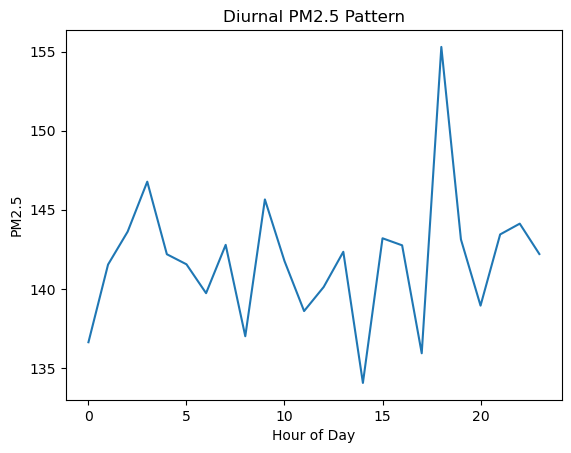

In [70]:
import matplotlib.pyplot as plt

diurnal_profile['PM2.5'].plot()
plt.title("Diurnal PM2.5 Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5")
plt.show()

In [84]:
#11... ->

df['TS'] = pd.to_datetime(df['TS'])

df['Hour'] = df['TS'].dt.hour
df['Day'] = df['TS'].dt.day

df['Temperature'] = 25 + 5*np.sin((df['Hour']-6)/24 * 2*np.pi)

df['RH'] = 70 - 10*np.sin((df['Hour'])/24 * 2*np.pi)

np.random.seed(42)
df['Wind_Speed'] = np.random.uniform(1,5,len(df))

print(df[['TS','Temperature','RH','Wind_Speed']].head())

          TS  Temperature    RH  Wind_Speed
0 2025-01-01         20.0  70.0    2.498160
1 2025-01-01         20.0  70.0    4.802857
2 2025-01-01         20.0  70.0    3.927976
3 2025-01-01         20.0  70.0    3.394634
4 2025-01-01         20.0  70.0    1.624075


In [86]:
#12... ->

emission_factors = {
    'Boiler': 1.2,
    'Diesel Generator': 2.0,
    'Thermal Plant': 1.8,
    'Furnace': 1.5
}

df['Emission_Factor'] = df['Source_Type'].map(emission_factors)
df['Estimated_Emission_PM25'] = df['Flow_Rate_m3_hr'] * df['Emission_Factor']
sector_emissions = df.groupby('Source_Type')['Estimated_Emission_PM25'].mean()
print(sector_emissions)

Source_Type
Ambient   NaN
Stack     NaN
Unknown   NaN
Name: Estimated_Emission_PM25, dtype: float64


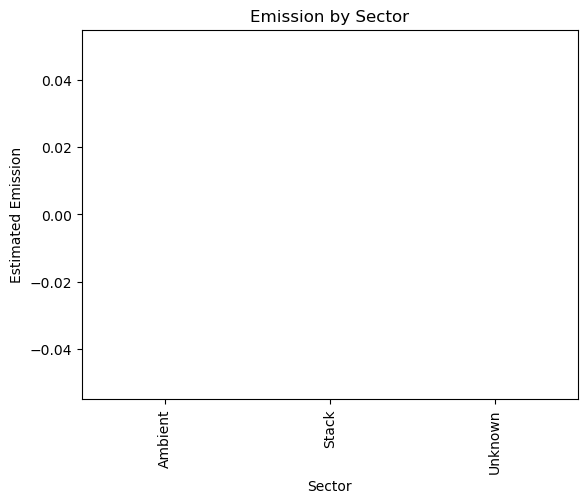

In [88]:
import matplotlib.pyplot as plt

sector_emissions.plot(kind='bar')
plt.title("Emission by Sector")
plt.xlabel("Sector")
plt.ylabel("Estimated Emission")
plt.show()

In [90]:
print(df['Source_Type'].unique())

['Stack' 'Ambient' 'Unknown']


In [92]:
emission_factors = {
    'Stack': 1.8,
    'Ambient': 0.8,
    'Unknown': 1.0
}

In [94]:
df['Emission_Factor'] = df['Source_Type'].map(emission_factors)

In [96]:
df['Estimated_Emission_PM25'] = df['Flow_Rate_m3_hr'] * df['Emission_Factor']

In [98]:
sector_emissions = df.groupby('Source_Type')['Estimated_Emission_PM25'].mean()

print(sector_emissions)

Source_Type
Ambient       0.000000
Stack      5411.320725
Unknown            NaN
Name: Estimated_Emission_PM25, dtype: float64


In [100]:
emission_factors = {
    'Stack': 1.8,
    'Ambient': 0.5,
    'Unknown': 1.0
}

In [102]:
df['Emission_Factor'] = df['Source_Type'].map(emission_factors)

df['Estimated_Emission_PM25'] = df['Flow_Rate_m3_hr'] * df['Emission_Factor']

sector_emissions = df.groupby('Source_Type')['Estimated_Emission_PM25'].mean()

print(sector_emissions)

Source_Type
Ambient       0.000000
Stack      5411.320725
Unknown            NaN
Name: Estimated_Emission_PM25, dtype: float64


In [105]:
#Q13... ->

df = df.sort_values('TS')

df['PM25_Change'] = df['PM2.5'].diff()
threshold = df['PM25_Change'].std() * 3
df['Drift_Alarm'] = abs(df['PM25_Change']) > threshold
drift_events = df[df['Drift_Alarm'] == True]

print(drift_events[['TS','PM2.5','PM25_Change','Drift_Alarm']])

                       TS    PM2.5  PM25_Change  Drift_Alarm
182   2025-01-01 04:30:00   952.86       805.11         True
183   2025-01-01 04:30:00   103.91      -848.95         True
450   2025-01-01 11:15:00   979.90       826.19         True
451   2025-01-01 11:15:00   273.80      -706.10         True
613   2025-01-01 15:15:00  2272.00      2165.33         True
...                   ...      ...          ...          ...
27031 2025-01-29 03:45:00   212.55      -767.35         True
27065 2025-01-29 04:30:00  2475.25      2282.77         True
27062 2025-01-29 04:30:00    84.86     -2390.39         True
28215 2025-01-30 09:15:00  2475.25      2361.35         True
28223 2025-01-30 09:30:00    23.27     -2451.98         True

[147 rows x 4 columns]


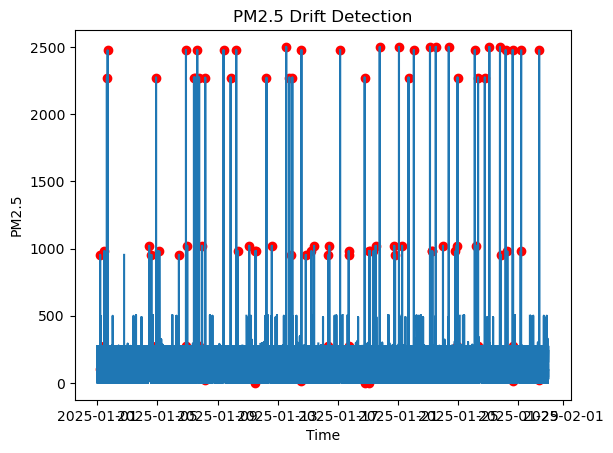

In [107]:
import matplotlib.pyplot as plt

plt.plot(df['TS'], df['PM2.5'])
plt.scatter(df[df['Drift_Alarm']]['TS'],
            df[df['Drift_Alarm']]['PM2.5'],
            color='red')

plt.title("PM2.5 Drift Detection")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.show()

In [111]:
#Q14....->

df['PM25_raw'] = df['PM2.5']
df['PM2.5'] = df['PM2.5'].fillna(df['PM2.5'].mean())

mae = (abs(df['PM25_raw'] - df['PM2.5'])).mean()
print("MAE:", mae)

rmse = ((df['PM25_raw'] - df['PM2.5'])**2).mean()**0.5
print("RMSE:", rmse)

mape = (abs((df['PM25_raw'] - df['PM2.5']) / df['PM25_raw'])).mean()*100
print("MAPE:", mape)

MAE: 0.0
RMSE: 0.0
MAPE: 0.0


In [115]:
#Q15....->

stack_report = df[df['Source_Type'] == 'Stack'].groupby(['Plant_ID','Stack_ID']).agg({
'PM2.5':'mean',
'SO2':'mean',
'NOx':'mean',
'Any_Exceedance':'sum'
}).reset_index()

print(stack_report)

ambient_report = df[df['Source_Type'] == 'Ambient'].groupby('Plant_ID').agg({
'PM2.5':'mean',
'SO2':'mean',
'NOx':'mean',
'AQI_Overall':'mean'
}).reset_index()

print(ambient_report)

  Plant_ID Stack_ID       PM2.5         SO2         NOx  Any_Exceedance
0    PL-01     S-01  141.785461  146.913517  144.581416            2563
1    PL-01     S-02  143.002545  147.906911  151.468546            2574
2    PL-02     S-01  135.836243  148.328030  141.087689            2529
3    PL-03     S-01  140.081954  135.860411  135.279199            2535
4    PL-03     S-02  148.395442  158.267192  146.803654            2592
5    PL-03     S-03  148.824035  154.041483  146.113559            2556
     Plant_ID       PM2.5         SO2         NOx  AQI_Overall
0  LOC-BLR-01  141.290650  143.291595  140.989030   295.714233
1  LOC-DEL-01  140.093967  142.808313  142.823018   293.439685
2  LOC-DEL-02  141.233079  140.281258  140.896588   295.589579
3  LOC-MUM-01  137.364488  141.804973  137.364001   287.157570


In [117]:
#Q16....->

# Time features
df['Hour'] = df['TS'].dt.hour
df['DayOfWeek'] = df['TS'].dt.dayofweek
df['Month'] = df['TS'].dt.month

df['PM25_lag1'] = df['PM2.5'].shift(1)
df['PM25_lag3'] = df['PM2.5'].shift(3)

df['PM25_roll24'] = df['PM2.5'].rolling(24).mean()

features = df[['Hour','DayOfWeek','Month',
               'Temperature','RH','Wind_Speed',
               'PM25_lag1','PM25_lag3','PM25_roll24']]

print(features.head())

   Hour  DayOfWeek  Month  Temperature    RH  Wind_Speed  PM25_lag1  \
0   0.0        2.0    1.0         20.0  70.0    2.498160        NaN   
1   0.0        2.0    1.0         20.0  70.0    4.802857     166.47   
2   0.0        2.0    1.0         20.0  70.0    3.927976       0.82   
3   0.0        2.0    1.0         20.0  70.0    3.394634     273.80   
4   0.0        2.0    1.0         20.0  70.0    1.624075     106.36   

   PM25_lag3  PM25_roll24  
0        NaN          NaN  
1        NaN          NaN  
2        NaN          NaN  
3     166.47          NaN  
4       0.82          NaN  


In [119]:
#Q17....->

hotspots = df.groupby('Plant_ID').agg({
'PM2.5':['mean','max','count']
})

hotspots.columns = ['Avg_PM25','Max_PM25','Persistence']

hotspots['Hotspot_Score'] = hotspots['Avg_PM25'] * hotspots['Persistence']
hotspots = hotspots.sort_values('Hotspot_Score', ascending=False)
print(hotspots)

              Avg_PM25  Max_PM25  Persistence  Hotspot_Score
Plant_ID                                                    
PL-03       145.763057   2499.90         7901   1.151674e+06
PL-01       142.396073   1020.20         5292   7.535600e+05
LOC-DEL-02  141.233079    505.05         2655   3.749738e+05
LOC-BLR-01  141.290650    499.80         2643   3.734312e+05
LOC-DEL-01  140.093967    499.90         2656   3.720896e+05
LOC-MUM-01  137.364488    490.29         2630   3.612686e+05
PL-02       135.836243    952.86         2608   3.542609e+05


In [121]:
#Q18...->

control_date = '2024-07-01'

pre_control = df[df['TS'] < control_date]['PM2.5'].mean()
post_control = df[df['TS'] >= control_date]['PM2.5'].mean()

impact = pre_control - post_control

print("Pre Control PM2.5:", pre_control)
print("Post Control PM2.5:", post_control)
print("Reduction:", impact)

Pre Control PM2.5: nan
Post Control PM2.5: 141.79488535578534
Reduction: nan


In [123]:
#Q19....->

penalty_rate = 10000
penalties = df.groupby('Plant_ID')['Any_Exceedance'].sum()
penalties = penalties * penalty_rate
print(penalties)

Plant_ID
LOC-BLR-01    25640000
LOC-DEL-01    25890000
LOC-DEL-02    25900000
LOC-MUM-01    25500000
PL-01         51370000
PL-02         25290000
PL-03         76830000
Name: Any_Exceedance, dtype: int64


In [125]:
#Q20...->

open_data = df.drop(columns=['Plant_ID','Stack_ID'])
open_data.to_csv("open_air_quality_data.csv", index=False)
print(open_data.head())

  Record_ID  Flow_Rate_m3_hr         TS   PM2.5     SO2     NOx   Unit Status  \
0    E00001           2033.5 2025-01-01  166.47  116.47  100.88  ug/m3  FAULT   
1    E00002           3377.9 2025-01-01    0.82   95.92   32.04  ug/m3  MAINT   
2    E00003           3798.4 2025-01-01  273.80     NaN  267.00  ug/m3  FAULT   
3    E00004           3121.2 2025-01-01  106.36  133.00   90.91  ug/m3     OK   
4    E00005           3700.5 2025-01-01  273.80  275.70  267.00  ug/m3  FAULT   

           Lat_Lon Source_Type  ... Wind_Speed Emission_Factor  \
0   13.083,80.2702       Stack  ...   2.498160             1.8   
1  13.0839,80.2721       Stack  ...   4.802857             1.8   
2  19.0763,72.8777       Stack  ...   3.927976             1.8   
3  12.9719,77.5955       Stack  ...   3.394634             1.8   
4  12.9722,77.5941       Stack  ...   1.624075             1.8   

   Estimated_Emission_PM25  PM25_Change  Drift_Alarm  PM25_raw  DayOfWeek  \
0                  3660.30          NaN